# Part A:

In [1]:
import numpy as np

def generate_data(n, noise=0.0, seed=None):
  if seed is not None:
    np.random.seed(seed)

  X = np.random.randn(n)
  Y = (X > 0).astype(int)

  # Flip labels with probability noise
  flips = np.random.rand(n) < noise
  Y[flips] = 1 - Y[flips]

  return X, Y

In [2]:
def classifier(x):
  return (x > 0).astype(int)

In [3]:
eta_noise = [0, 0.1, 0.2, 0.4]
sample_size_n = [10, 20, 50, 100, 500, 1000]

In [4]:
def empirical_error(X, Y):
    preds = classifier(X)
    return np.mean(preds != Y)

def true_error(noise, test_size=100000):
    X_test, Y_test = generate_data(test_size, noise=noise)
    preds = classifier(X_test)
    return np.mean(preds != Y_test)

In [5]:
num_trials = 50

results = {}
for eta in eta_noise:
    results[eta] = {}

    for n in sample_size_n:
        emp_errors = []
        true_errors = []

        for _ in range(num_trials):
            X_train, Y_train = generate_data(n, noise=eta)

            emp_err = empirical_error(X_train, Y_train)
            # print(emp_err)
            emp_errors.append(emp_err)
            # print(emp_errors)

            true_err = true_error(eta)
            # print(true_err)
            true_errors.append(true_err)
            # print(true_errors)

        results[eta][n] = {
            "avg_empirical_error": np.mean(emp_errors),
            "avg_true_error": np.mean(true_errors)
        }

In [6]:
results

{0: {10: {'avg_empirical_error': np.float64(0.0),
   'avg_true_error': np.float64(0.0)},
  20: {'avg_empirical_error': np.float64(0.0),
   'avg_true_error': np.float64(0.0)},
  50: {'avg_empirical_error': np.float64(0.0),
   'avg_true_error': np.float64(0.0)},
  100: {'avg_empirical_error': np.float64(0.0),
   'avg_true_error': np.float64(0.0)},
  500: {'avg_empirical_error': np.float64(0.0),
   'avg_true_error': np.float64(0.0)},
  1000: {'avg_empirical_error': np.float64(0.0),
   'avg_true_error': np.float64(0.0)}},
 0.1: {10: {'avg_empirical_error': np.float64(0.08200000000000002),
   'avg_true_error': np.float64(0.0999664)},
  20: {'avg_empirical_error': np.float64(0.09499999999999999),
   'avg_true_error': np.float64(0.10012700000000001)},
  50: {'avg_empirical_error': np.float64(0.09119999999999999),
   'avg_true_error': np.float64(0.100213)},
  100: {'avg_empirical_error': np.float64(0.1058),
   'avg_true_error': np.float64(0.099609)},
  500: {'avg_empirical_error': np.float64(0

In [7]:
for eta in results:
    print(f"\nNoise eta = {eta}")
    print("-" * 50)
    for n in results[eta]:
        emp = results[eta][n]["avg_empirical_error"]
        true = results[eta][n]["avg_true_error"]
        print(f"n= {n:4d} | Empirical Error= {emp:.4f} | True Error= {true:.4f}")


Noise eta = 0
--------------------------------------------------
n=   10 | Empirical Error= 0.0000 | True Error= 0.0000
n=   20 | Empirical Error= 0.0000 | True Error= 0.0000
n=   50 | Empirical Error= 0.0000 | True Error= 0.0000
n=  100 | Empirical Error= 0.0000 | True Error= 0.0000
n=  500 | Empirical Error= 0.0000 | True Error= 0.0000
n= 1000 | Empirical Error= 0.0000 | True Error= 0.0000

Noise eta = 0.1
--------------------------------------------------
n=   10 | Empirical Error= 0.0820 | True Error= 0.1000
n=   20 | Empirical Error= 0.0950 | True Error= 0.1001
n=   50 | Empirical Error= 0.0912 | True Error= 0.1002
n=  100 | Empirical Error= 0.1058 | True Error= 0.0996
n=  500 | Empirical Error= 0.1002 | True Error= 0.1001
n= 1000 | Empirical Error= 0.1002 | True Error= 0.1000

Noise eta = 0.2
--------------------------------------------------
n=   10 | Empirical Error= 0.1720 | True Error= 0.2001
n=   20 | Empirical Error= 0.2250 | True Error= 0.2004
n=   50 | Empirical Error= 0

In [8]:
delta = 0.05

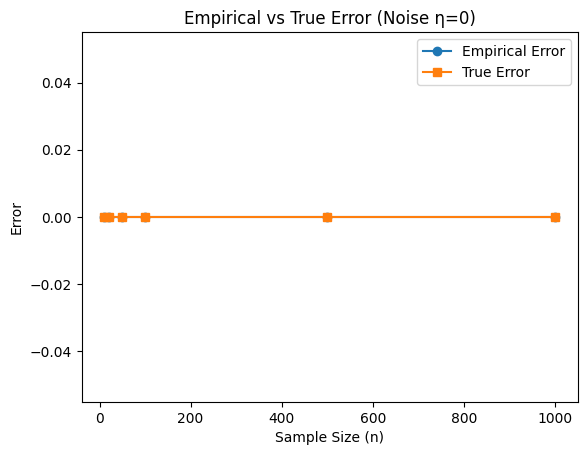

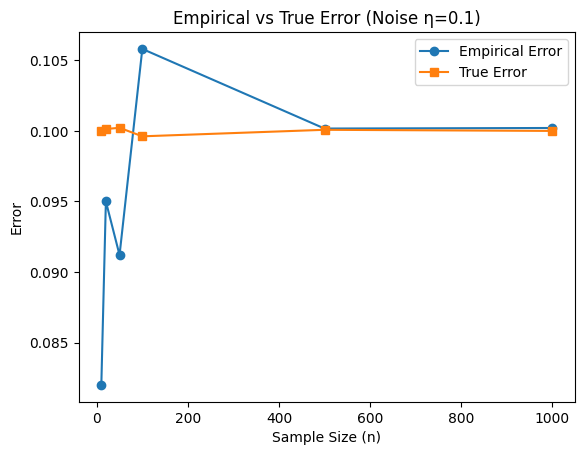

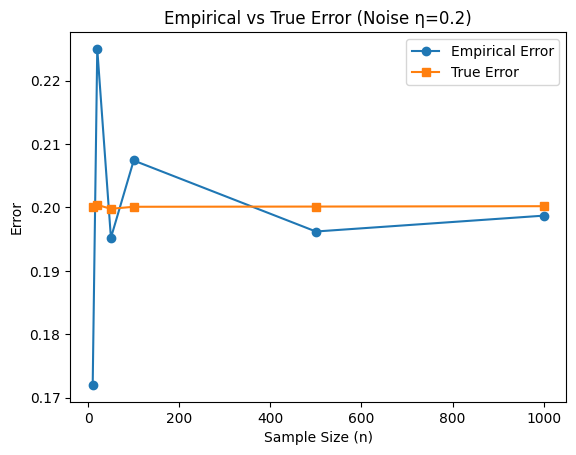

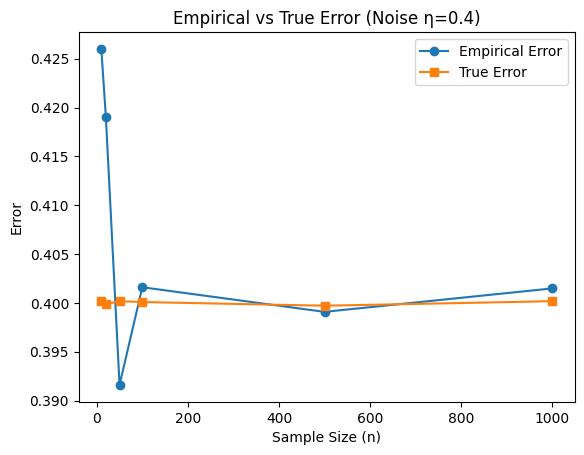

In [9]:
import matplotlib.pyplot as plt

for eta in eta_noise:
    n_values = []
    emp_vals = []
    true_vals = []

    for n in sample_size_n:
        n_values.append(n)
        emp_vals.append(results[eta][n]["avg_empirical_error"])
        true_vals.append(results[eta][n]["avg_true_error"])

    plt.figure()
    plt.plot(n_values, emp_vals, marker='o', label="Empirical Error")
    plt.plot(n_values, true_vals, marker='s', label="True Error")
    plt.xlabel("Sample Size (n)")
    plt.ylabel("Error")
    plt.title(f"Empirical vs True Error (Noise η={eta})")
    plt.legend()
    plt.show()

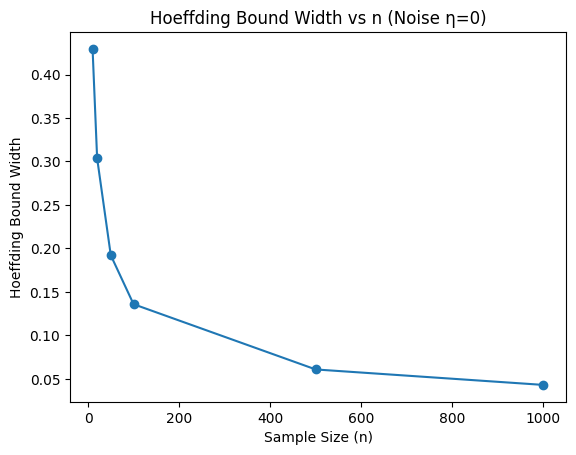

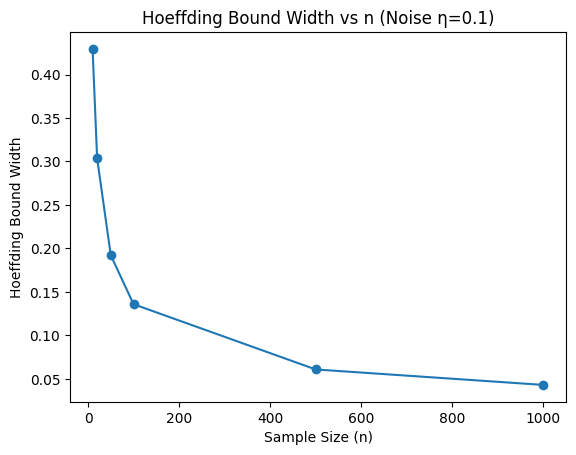

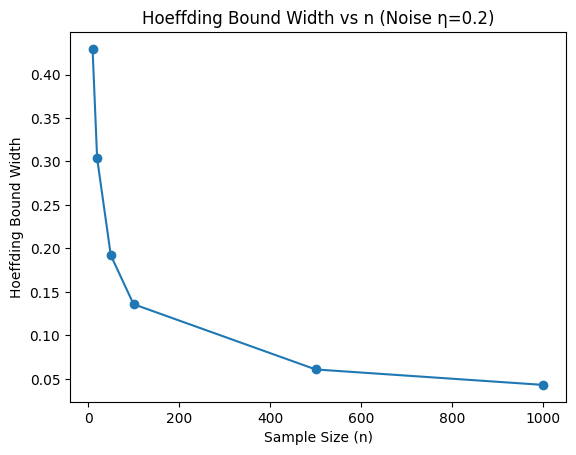

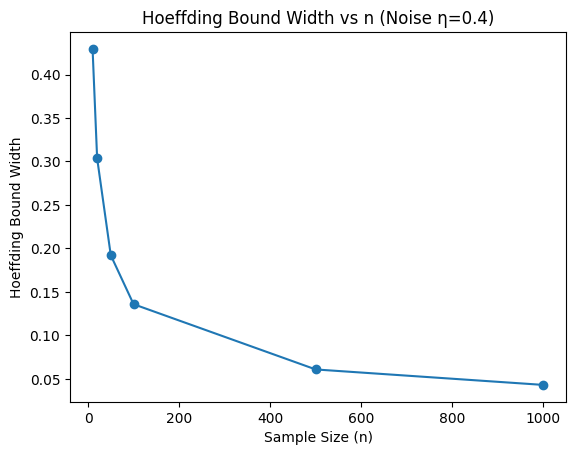

In [10]:
for eta in eta_noise:
    n_values = []
    bound_width = []

    for n in sample_size_n:
        epsilon = np.sqrt(np.log(2/delta) / (2*n))
        n_values.append(n)
        bound_width.append(epsilon)

    plt.figure()
    plt.plot(n_values, bound_width, marker='o')
    plt.xlabel("Sample Size (n)")
    plt.ylabel("Hoeffding Bound Width")
    plt.title(f"Hoeffding Bound Width vs n (Noise η={eta})")
    plt.show()


# Question-Answers:

## Q1. Why does the bound shrink with ( n )?
### A1. Epsilon is inversely proportional to 1/sqrt(n). So, as n increases, the denominator grows bigger, so epsilon decreases. So, as the data increases, the bound will get tighter.

## Q2. Why does noise not appear in Hoeffding’s bound?
### A2. Hoeffding's inequality only bounds the GAP between empirical error and true error, regardless of what the true error actually is. Noise increases the absolute value of the true error, but it does not affect how well the empirical error estimates the true error. The bound controls concentration of the estimator, not its value. It is distribution-free.

## Q3. Is the bound tight or loose in practice?
### A3. The bound is loose in practice. We see that, True error ~ eta, Empirical error quickly converges but Hoeffding bound width remains much larger.

# Part B:

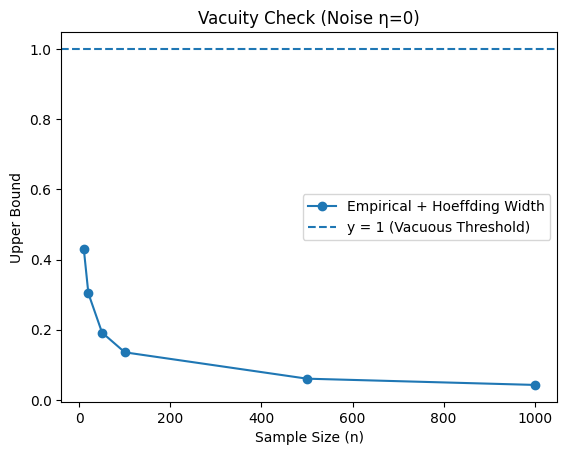

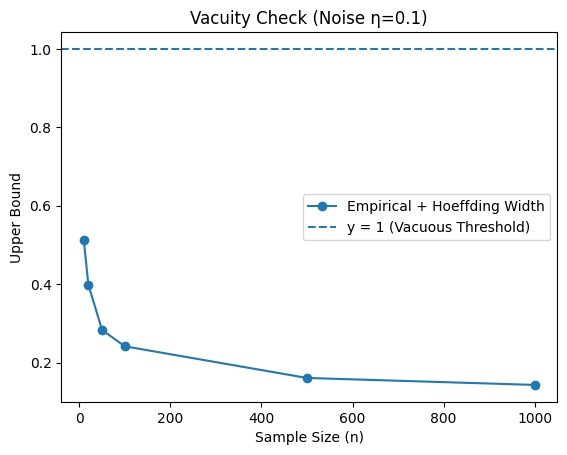

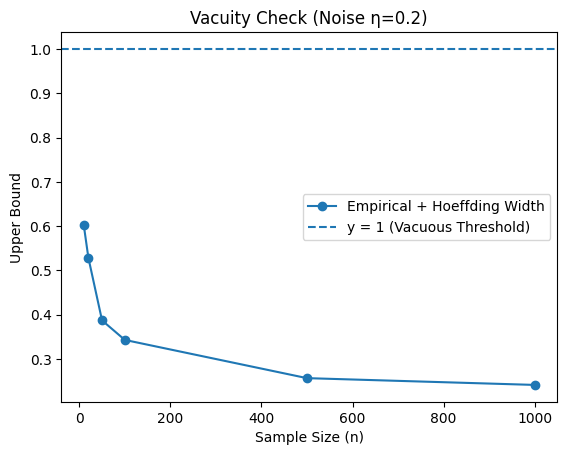

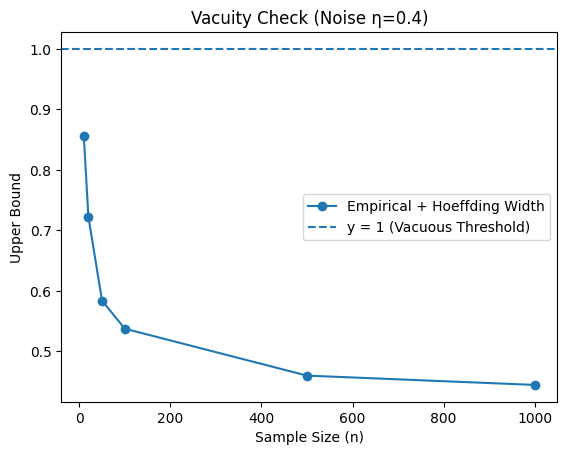

In [11]:
delta = 0.05

for eta in eta_noise:
    n_vals = []
    bound_vals = []

    for n in sample_size_n:
        emp = results[eta][n]["avg_empirical_error"]
        epsilon = np.sqrt(np.log(2/delta)/(2*n))
        bound_upper = emp + epsilon

        n_vals.append(n)
        bound_vals.append(bound_upper)
        # print(epsilon)

    plt.figure()
    plt.plot(n_vals, bound_vals, marker='o', label="Empirical + Hoeffding Width")
    plt.axhline(y=1, linestyle='--', label="y = 1 (Vacuous Threshold)")

    plt.xlabel("Sample Size (n)")
    plt.ylabel("Upper Bound")
    plt.title(f"Vacuity Check (Noise η={eta})")
    plt.legend()
    plt.show()

# Question-Answers:

## Q1. At which ( n ) does the bound become non-vacuous?
### A1. From our experiment:-
- n=10  : Bound is NON-VACUOUS
- n=20  : Bound is NON-VACUOUS
- n=50  : Bound is NON-VACUOUS
- n=100 : Bound is NON-VACUOUS
### The bound first becomes non-vacuous at n = 10. This is because epsilon(n) = sqrt(log(2/0.05)/2n) drops below a meaningful threshold only when n is large enough.

## Q2. Does vacuity imply failure of learning?
### A2. No. Even if a bound were vacuous (i.e., > 1), it would only mean: the theoretical guarantee is too loose & the inequality gives no useful information.

## Q3. Why is Hoeffding pessimistic for small (n)?
### A3. For small n, the bound needs to see for the possibility that the n samples could be unrepresentative of the true distribution in the worst case. The formula epsilon decays slowly as (1/sqrt(n)), so for small n like 10 or 20, epsilon is very large. Additionally, Hoeffding does not use any knowledge about the specific hypothesis class or data distribution, making it overly conservative for simple problems like ours.

# Part C:

In [ ]:
def k_interval_predict(x, intervals):
  for a, b in intervals:
    if a <= x <= b:
      return 1
  return 0

def predict_all(X, intervals):
  return np.array([k_interval_predict(xi, intervals) for xi in X])


In [ ]:
def find_best_k_intervals(X, Y, k):
  n = len(X)
  sort_idx = np.argsort(X)
  X_sorted = X[sort_idx]
  Y_sorted = Y[sort_idx]

  eps = 1e-9
  boundaries = [-np.inf]
  for i in range(n - 1):
    boundaries.append((X_sorted[i] + X_sorted[i+1]) / 2)
  boundaries.append(np.inf)

  num_segments = len(boundaries) - 1

  gains = np.where(Y_sorted == 1, 1, -1)

  dp = np.full((num_segments + 1, k + 1), -np.inf)
  choice = np.full((num_segments + 1, k + 1, 2), -1, dtype=int)

  dp[0][0] = 0

  for i in range(1, num_segments + 1):
    for j in range(k + 1):
      if dp[i-1][j] != -np.inf:
        if dp[i][j] < dp[i-1][j]:
          dp[i][j] = dp[i-1][j]
          choice[i][j] = [-1, -1]

    for s in range(1, i + 1):
      interval_gain = np.sum(gains[s-1:i])
      for j in range(1, k + 1):
        if dp[s-1][j-1] != -np.inf:
          new_gain = dp[s-1][j-1] + interval_gain
          if new_gain > dp[i][j]:
            dp[i][j] = new_gain
            choice[i][j] = [s, i]

  best_gain = -np.inf
  best_j    = 0
  for j in range(k + 1):
    if dp[num_segments][j] > best_gain:
      best_gain = dp[num_segments][j]
      best_j    = j

  intervals = []
  i = num_segments
  j = best_j
  while j > 0 and i > 0:
    s, e = choice[i][j]
    if s == -1:
      i -= 1
    else:
      a = boundaries[s - 1]
      b = boundaries[e]
      intervals.append((a, b))
      i = s - 1
      j -= 1
  intervals.reverse()

  fixed_intervals = []
  for (a, b) in intervals:
    a_fixed = float(X_sorted[0] - 0.1) if np.isinf(a) else a
    b_fixed = float(X_sorted[-1] + 0.1) if np.isinf(b) else b
    fixed_intervals.append((a_fixed, b_fixed))

  return fixed_intervals


In [ ]:
def compute_training_error(X, Y, intervals):
  if len(intervals) == 0:
      predictions = np.zeros(len(X), dtype=int)
  else:
      predictions = predict_all(X, intervals)
  return np.mean(predictions != Y)

def compute_vc_bound_width(n, k, delta=0.05):
  d = 2 * k
  if d == 0:
    return np.sqrt(np.log(4 / delta) / n)

  inside = (d * (np.log(2 * n / d) + 1) + np.log(4 / delta)) / n
  inside = max(inside, 1e-10)
  return np.sqrt(inside)

In [13]:
n_train = 100
n_test = 100000
n_trials = 50
noise = 0.0
delta = 0.05
k_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

print(f"n_train={n_train}, n_test={n_test}, noise={noise}, trials={n_trials}")
print()

results_C = {
    'k': k_values,
    'train_errors': [],
    'test_errors': [],
    'vc_bounds': [],
    'vc_bound_widths':[]
}

for k in k_values:
  trial_train_errors = []
  trial_test_errors  = []

  for trial in range(n_trials):
    X_train, Y_train = generate_data(n_train, noise=noise)

    best_intervals = find_best_k_intervals(X_train, Y_train, k)

    train_err = compute_training_error(X_train, Y_train, best_intervals)
    trial_train_errors.append(train_err)

    X_test, Y_test = generate_data(n_test, noise=noise)
    if len(best_intervals) == 0:
      test_preds = np.zeros(len(X_test), dtype=int)
    else:
      test_preds = predict_all(X_test, best_intervals)
    test_err = np.mean(test_preds != Y_test)
    trial_test_errors.append(test_err)

  avg_train = np.mean(trial_train_errors)
  avg_test  = np.mean(trial_test_errors)

  vc_width = compute_vc_bound_width(n_train, k, delta)
  vc_bound = avg_train + vc_width

  results_C['train_errors'].append(avg_train)
  results_C['test_errors'].append(avg_test)
  results_C['vc_bounds'].append(vc_bound)
  results_C['vc_bound_widths'].append(vc_width)

  print(f"k={k:2d} | d=2k={2*k:2d} | "
        f"Train={avg_train:.4f} | "
        f"Test={avg_test:.4f} | "
        f"VC Width={vc_width:.4f} | "
        f"VC Bound={vc_bound:.4f}")
print()

n_train=100, n_test=100000, noise=0.0, trials=50

k= 1 | d=2k= 2 | Train=0.0000 | Test=0.0124 | VC Width=0.3949 | VC Bound=0.3949
k= 2 | d=2k= 4 | Train=0.0000 | Test=0.0123 | VC Width=0.4902 | VC Bound=0.4902
k= 3 | d=2k= 6 | Train=0.0000 | Test=0.0141 | VC Width=0.5605 | VC Bound=0.5605
k= 4 | d=2k= 8 | Train=0.0000 | Test=0.0129 | VC Width=0.6175 | VC Bound=0.6175
k= 5 | d=2k=10 | Train=0.0000 | Test=0.0146 | VC Width=0.6659 | VC Bound=0.6659
k= 6 | d=2k=12 | Train=0.0000 | Test=0.0124 | VC Width=0.7081 | VC Bound=0.7081
k= 7 | d=2k=14 | Train=0.0000 | Test=0.0117 | VC Width=0.7457 | VC Bound=0.7457
k= 8 | d=2k=16 | Train=0.0000 | Test=0.0130 | VC Width=0.7797 | VC Bound=0.7797
k= 9 | d=2k=18 | Train=0.0000 | Test=0.0112 | VC Width=0.8107 | VC Bound=0.8107
k=10 | d=2k=20 | Train=0.0000 | Test=0.0122 | VC Width=0.8392 | VC Bound=0.8392



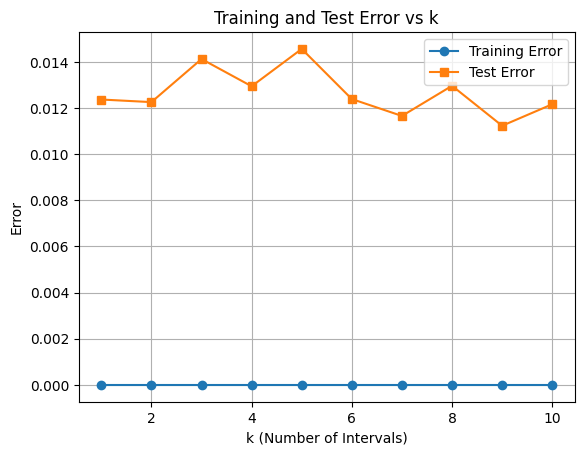

In [14]:
plt.figure()
plt.plot(results_C['k'], results_C['train_errors'], marker='o', label='Training Error')
plt.plot(results_C['k'], results_C['test_errors'], marker='s', label='Test Error')

plt.xlabel("k (Number of Intervals)")
plt.ylabel("Error")
plt.title("Training and Test Error vs k")
plt.legend()
plt.grid(True)
plt.show()

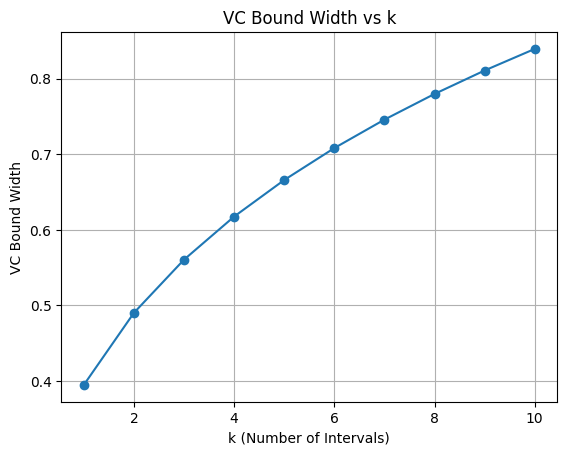

In [15]:
plt.figure()
plt.plot(results_C['k'], results_C['vc_bound_widths'], marker='o')

plt.xlabel("k (Number of Intervals)")
plt.ylabel("VC Bound Width")
plt.title("VC Bound Width vs k")
plt.grid(True)
plt.show()

# Question-Answers:

## Q1. Why does training error decrease with (k)?
### A1. Increasing k increases hypothesis flexibility, but since k = 1 is already expressive enough, the training error remains zero for all k.

## Q2. Why does test error stop improving?
### A2. Training error keeps dropping but test error plateaus or even increases. This is calledd OVERFITTING.

## Q3. How does the VC bound reflect this behavior?
### A3. As k increases:
- The training error L_hat(h) DECREASES (better fit)
- But the bound WIDTH sqrt(...) INCREASES (higher complexity penalty)
- The total VC bound = train error + width therefore INCREASES  
### This reflects the fundamental bias-variance tradeoff: the bound penalizes complexity to warn us that a more expressive model needs more data to generalize reliably.

# Part D:

In [16]:
n_train = 100
n_test = 100000
n_trials = 50
noise = 0.0
delta = 0.05
k_values  = [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20]

results_D = {
    'k': k_values,
    'train_errors': [],
    'test_errors': [],
    'vc_bound_widths': [],
    'vc_bounds': [],
    'generalization_gaps': []
}

results

{0: {10: {'avg_empirical_error': np.float64(0.0),
   'avg_true_error': np.float64(0.0)},
  20: {'avg_empirical_error': np.float64(0.0),
   'avg_true_error': np.float64(0.0)},
  50: {'avg_empirical_error': np.float64(0.0),
   'avg_true_error': np.float64(0.0)},
  100: {'avg_empirical_error': np.float64(0.0),
   'avg_true_error': np.float64(0.0)},
  500: {'avg_empirical_error': np.float64(0.0),
   'avg_true_error': np.float64(0.0)},
  1000: {'avg_empirical_error': np.float64(0.0),
   'avg_true_error': np.float64(0.0)}},
 0.1: {10: {'avg_empirical_error': np.float64(0.08200000000000002),
   'avg_true_error': np.float64(0.0999664)},
  20: {'avg_empirical_error': np.float64(0.09499999999999999),
   'avg_true_error': np.float64(0.10012700000000001)},
  50: {'avg_empirical_error': np.float64(0.09119999999999999),
   'avg_true_error': np.float64(0.100213)},
  100: {'avg_empirical_error': np.float64(0.1058),
   'avg_true_error': np.float64(0.099609)},
  500: {'avg_empirical_error': np.float64(0

In [17]:
for k in k_values:
  trial_train = []
  trial_test  = []
  for trial in range(n_trials):
    X_train, Y_train = generate_data(n_train, noise=noise)

    best_intervals = find_best_k_intervals(X_train, Y_train, k)

    train_err = compute_training_error(X_train, Y_train, best_intervals)
    trial_train.append(train_err)

    X_test, Y_test = generate_data(n_test, noise=noise)
    if len(best_intervals) == 0:
      test_preds = np.zeros(len(X_test), dtype=int)
    else:
      test_preds = predict_all(X_test, best_intervals)
    test_err = np.mean(test_preds != Y_test)
    trial_test.append(test_err)

  avg_train = np.mean(trial_train)
  avg_test  = np.mean(trial_test)

  vc_width  = compute_vc_bound_width(n_train, k, delta)
  vc_bound  = avg_train + vc_width
  gen_gap   = avg_test - avg_train
  results_D['train_errors'].append(avg_train)
  results_D['test_errors'].append(avg_test)
  results_D['vc_bound_widths'].append(vc_width)
  results_D['vc_bounds'].append(vc_bound)
  results_D['generalization_gaps'].append(gen_gap)

  overfit_flag = "*** OVERFITTING ***" if gen_gap > 0.05 else ""
  print(f"k={k:3d} | "
        f"Train={avg_train:.4f} | "
        f"Test={avg_test:.4f} | "
        f"Gap={gen_gap:+.4f} | "
        f"VC Width={vc_width:.4f} | "
        f"VC Bound={vc_bound:.4f}  {overfit_flag}")

k=  1 | Train=0.0000 | Test=0.0149 | Gap=+0.0149 | VC Width=0.3949 | VC Bound=0.3949  
k=  2 | Train=0.0000 | Test=0.0108 | Gap=+0.0108 | VC Width=0.4902 | VC Bound=0.4902  
k=  3 | Train=0.0000 | Test=0.0120 | Gap=+0.0120 | VC Width=0.5605 | VC Bound=0.5605  
k=  4 | Train=0.0000 | Test=0.0109 | Gap=+0.0109 | VC Width=0.6175 | VC Bound=0.6175  
k=  5 | Train=0.0000 | Test=0.0134 | Gap=+0.0134 | VC Width=0.6659 | VC Bound=0.6659  
k=  6 | Train=0.0000 | Test=0.0094 | Gap=+0.0094 | VC Width=0.7081 | VC Bound=0.7081  
k=  7 | Train=0.0000 | Test=0.0119 | Gap=+0.0119 | VC Width=0.7457 | VC Bound=0.7457  
k=  8 | Train=0.0000 | Test=0.0134 | Gap=+0.0134 | VC Width=0.7797 | VC Bound=0.7797  
k= 10 | Train=0.0000 | Test=0.0115 | Gap=+0.0115 | VC Width=0.8392 | VC Bound=0.8392  
k= 12 | Train=0.0000 | Test=0.0118 | Gap=+0.0118 | VC Width=0.8903 | VC Bound=0.8903  
k= 15 | Train=0.0000 | Test=0.0143 | Gap=+0.0143 | VC Width=0.9555 | VC Bound=0.9555  
k= 20 | Train=0.0000 | Test=0.0109 | Gap=+0

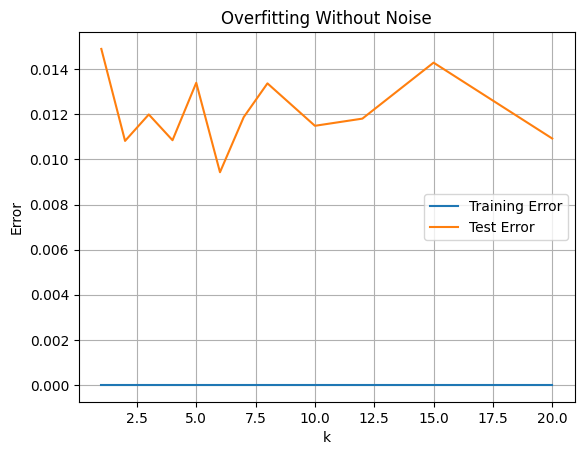

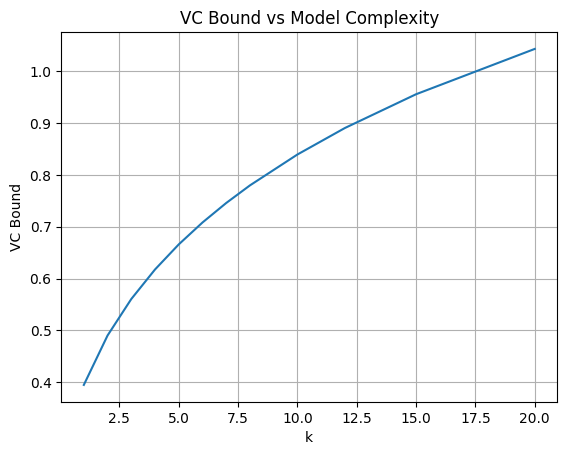

In [18]:
plt.figure()
plt.plot(results_D['k'], results_D['train_errors'], label='Training Error')
plt.plot(results_D['k'], results_D['test_errors'], label='Test Error')
plt.xlabel("k")
plt.ylabel("Error")
plt.title("Overfitting Without Noise")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(results_D['k'], results_D['vc_bounds'], label='VC Bound')
plt.xlabel("k")
plt.ylabel("VC Bound")
plt.title("VC Bound vs Model Complexity")
plt.grid(True)
plt.show()

# Question-Answers:

## Q1. Why does overfitting occur even when labels are correct?
### A1. Overfitting occurs even when labels are correct because the training dataset is finite and does not perfectly represent the true distribution. As the number of intervals k increases, the hypothesis class becomes more flexible and can fit small sampling fluctuations that are specific to the training data. These fluctuations are not part of the true underlying rule. Although the training error remains zero, the test error does not improve and may slightly increase. Therefore, overfitting is caused by excessive model complexity relative to the sample size, not necessarily by label noise.

# Part E:

In [19]:
import numpy as np
import matplotlib.pyplot as plt

delta = 0.05
k = 1
noise = 0.0

n_values = [20, 50, 100, 200, 500, 1000]

hoeff_bounds = []
vc_bounds = []

for n in n_values:

    X_train, Y_train = generate_data(n, noise=noise)
    best_intervals = find_best_k_intervals(X_train, Y_train, k)

    train_err = compute_training_error(X_train, Y_train, best_intervals)

    # Hoeffding
    epsilon_hoeff = np.sqrt(np.log(2/delta)/(2*n))
    hoeff_bounds.append(train_err + epsilon_hoeff)

    # VC
    vc_width = compute_vc_bound_width(n, k, delta)
    vc_bounds.append(train_err + vc_width)

print("Hoeffding Bounds:", hoeff_bounds)
print("VC Bounds:", vc_bounds)

Hoeffding Bounds: [np.float64(0.3036807309541526), np.float64(0.19206455826398416), np.float64(0.13581015157406195), np.float64(0.09603227913199208), np.float64(0.060736146190830516), np.float64(0.04294694083467376)]
VC Bounds: [np.float64(0.7865586812750166), np.float64(0.5330304427615776), np.float64(0.3948717134291853), np.float64(0.2913645600254941), np.float64(0.19396516610731043), np.float64(0.1421180396453531)]


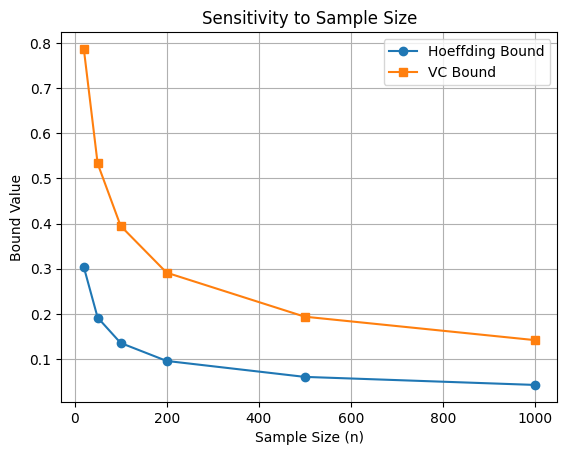

In [20]:
plt.figure()
plt.plot(n_values, hoeff_bounds, marker='o', label='Hoeffding Bound')
plt.plot(n_values, vc_bounds, marker='s', label='VC Bound')
plt.xlabel("Sample Size (n)")
plt.ylabel("Bound Value")
plt.title("Sensitivity to Sample Size")
plt.legend()
plt.grid(True)
plt.show()

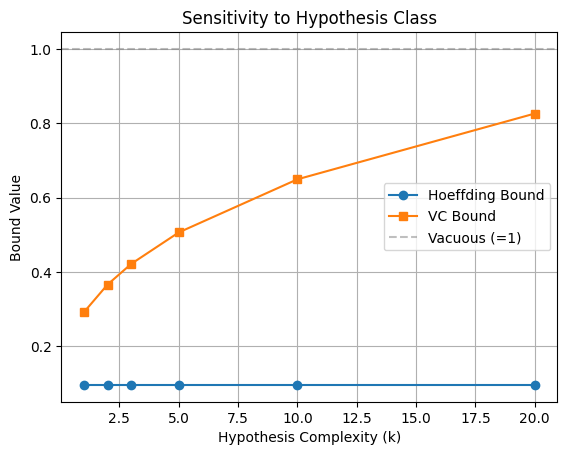

Hoeffding bounds: ['0.096', '0.096', '0.096', '0.096', '0.096', '0.096']
VC bounds: ['0.291', '0.366', '0.422', '0.506', '0.649', '0.826']


In [21]:
k_values = [1, 2, 3, 5, 10, 20]
n_fixed = 200
delta = 0.05
noise = 0.0

hoeff_by_k = []
vc_by_k = []

for k in k_values:
    X_train, Y_train = generate_data(n_fixed, noise=noise)
    best_intervals = find_best_k_intervals(X_train, Y_train, k)
    train_err = compute_training_error(X_train, Y_train, best_intervals)

    epsilon_hoeff = np.sqrt(np.log(2/delta)/(2*n_fixed))
    hoeff_by_k.append(train_err + epsilon_hoeff)

    vc_width = compute_vc_bound_width(n_fixed, k, delta)
    vc_by_k.append(train_err + vc_width)

plt.figure()
plt.plot(k_values, hoeff_by_k, marker='o', label='Hoeffding Bound')
plt.plot(k_values, vc_by_k, marker='s', label='VC Bound')
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Vacuous (=1)')
plt.xlabel("Hypothesis Complexity (k)")
plt.ylabel("Bound Value")
plt.title("Sensitivity to Hypothesis Class")
plt.legend()
plt.grid(True)
plt.show()

print(f"Hoeffding bounds: {[f'{b:.3f}' for b in hoeff_by_k]}")
print(f"VC bounds: {[f'{b:.3f}' for b in vc_by_k]}")

# Question-Answers:

## Q1. Which bound would you trust more when designing a learning algorithm, and why?
### A1. I would trust the VC bound more when designing a learning algorithm. Because VC bound depends on Sample size & Hypothesis complexity. So VC bound captures the bias–variance tradeoff.